In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 200
Columns: 4


In [6]:
df.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [7]:
df.dtypes

TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
df.head

<bound method NDFrame.head of         TV  Radio  Newspaper  Sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3    9.3
3    151.5   41.3       58.5   18.5
4    180.8   10.8       58.4   12.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1    9.7
197  177.0    9.3        6.4   12.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   13.4

[200 rows x 4 columns]>

In [10]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

TV           0.0
Radio        0.0
Newspaper    0.0
Sales        0.0
dtype: float64

In [13]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [14]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


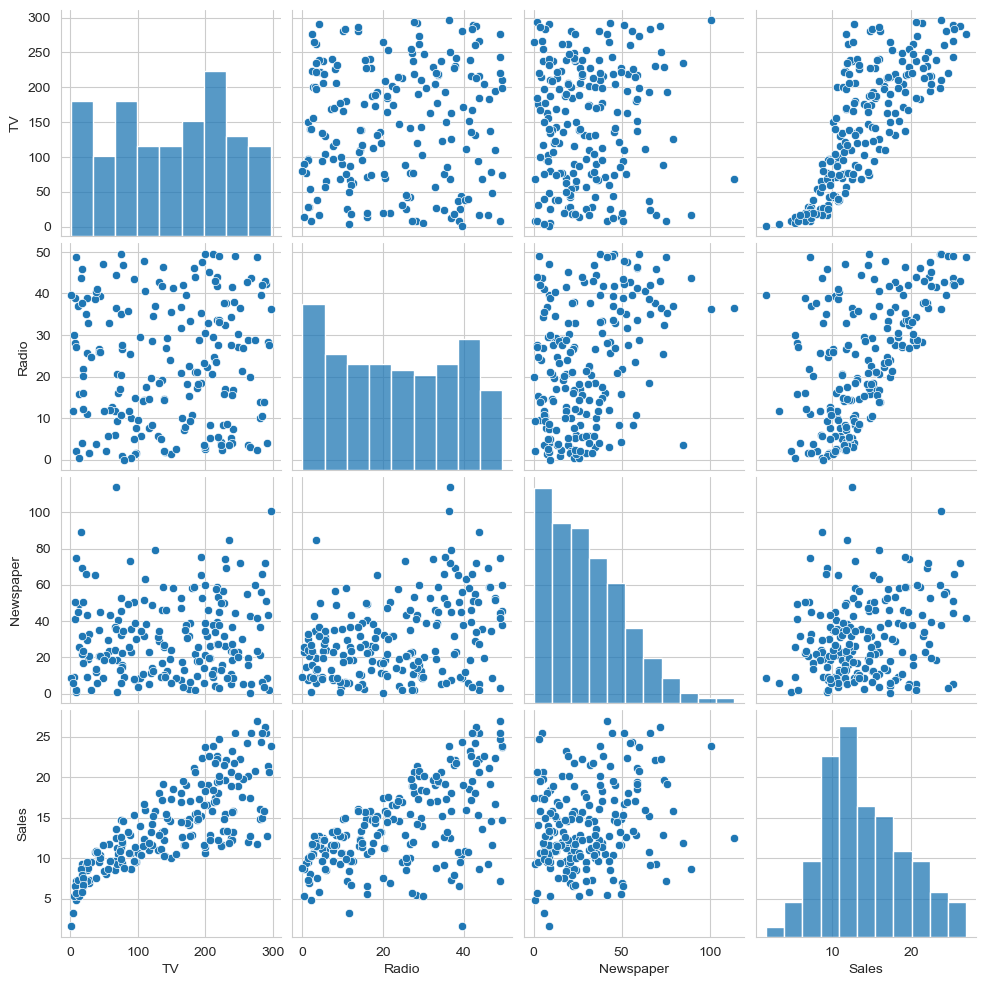

In [15]:
sns.pairplot(df)

plt.show()

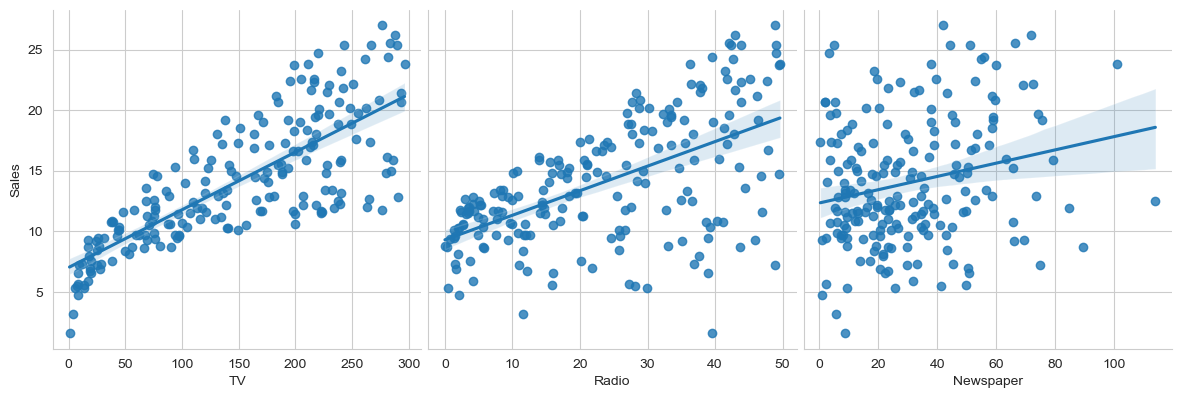

In [16]:
sns.pairplot(
    df,
    x_vars=['TV', 'Radio', 'Newspaper'],
    y_vars='Sales',
    height=4,
    kind='reg'
)

plt.show()

Observation

The pairplot shows the relationships between advertising expenditure and sales. The relationship between TV advertising and sales appears more strongly linear than the relationships involving Radio and Newspaper advertising. The plots also help identify the distribution of each variable and possible outliers.

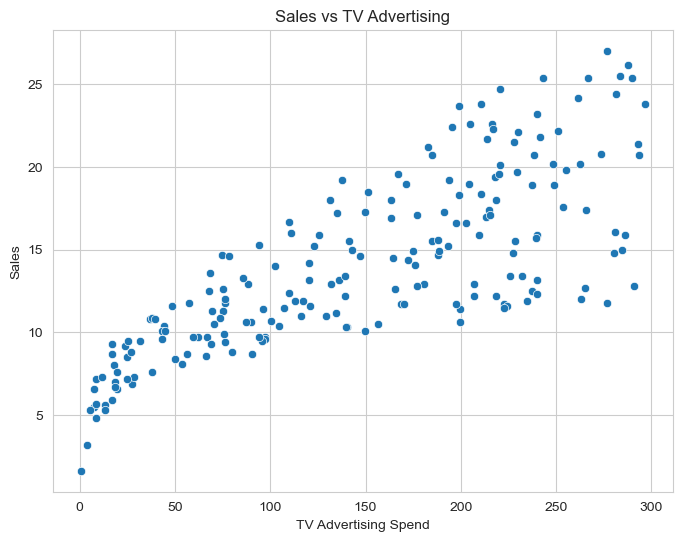

In [17]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='TV',
    y='Sales'
)

plt.title("Sales vs TV Advertising")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

Observation

The scatter plot shows a clear positive relationship between TV advertising expenditure and sales. As TV advertising spending increases, sales generally tend to increase.

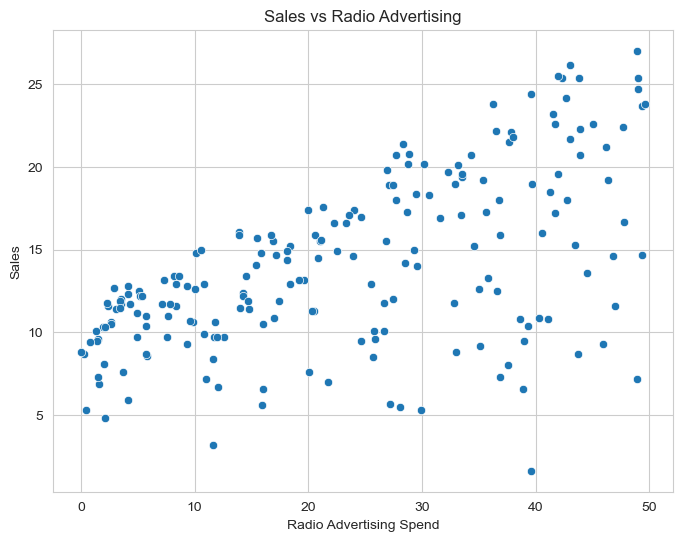

In [18]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Radio',
    y='Sales'
)

plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

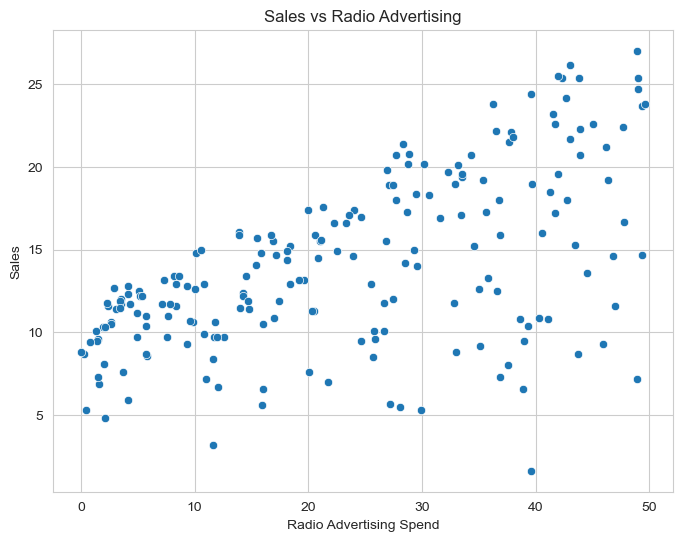

In [19]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Radio',
    y='Sales'
)

plt.title("Sales vs Radio Advertising")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

Observation

Radio advertising also shows a positive relationship with sales, although the relationship appears different in strength and pattern from TV advertising.

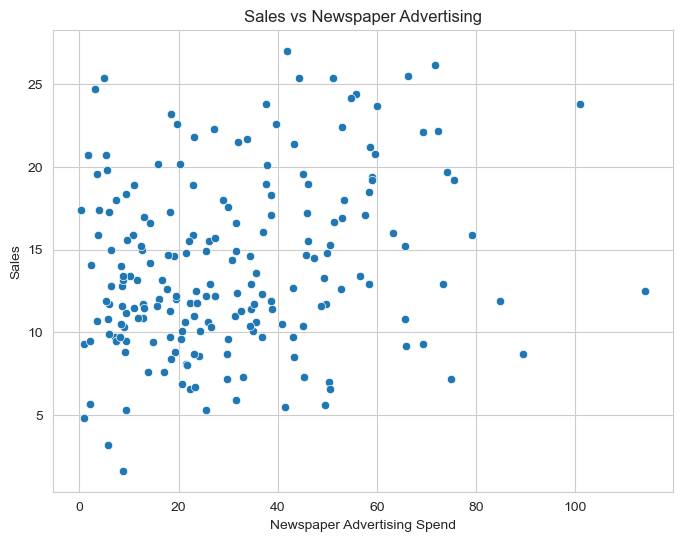

In [20]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Newspaper',
    y='Sales'
)

plt.title("Sales vs Newspaper Advertising")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

Observation

The relationship between Newspaper advertising expenditure and sales appears weaker than the relationships observed for TV and Radio. This can also be examined quantitatively using correlation and regression coefficients.

In [21]:
correlation_matrix = df.corr()

correlation_matrix

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


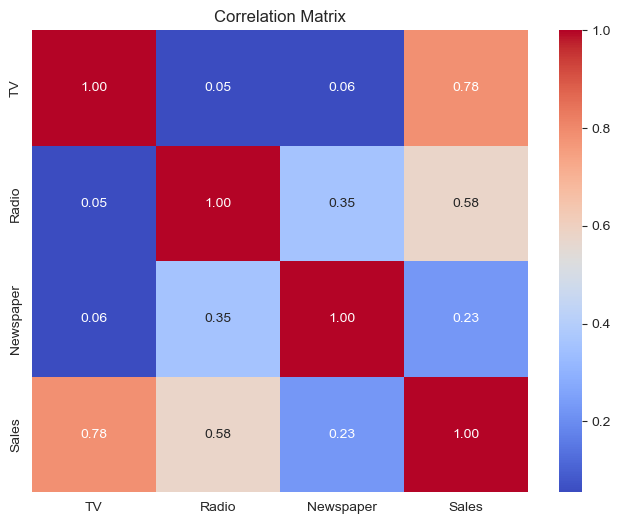

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

Observation

The correlation matrix shows the linear relationship between each advertising channel and sales. A correlation value closer to +1 indicates a stronger positive linear association, while a value closer to 0 indicates a weaker linear association. Correlation does not by itself establish causation.

In [24]:
X = df[['TV', 'Radio', 'Newspaper']]

In [25]:
y = df['Sales']

In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200, 3)
y shape: (200,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [28]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (160, 3)
Testing features: (40, 3)
Training target: (160,)
Testing target: (40,)


In [29]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
linear_predictions = linear_model.predict(X_test)

In [31]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': linear_predictions
})

comparison.head(10)

,Actual,Predicted
0,16.9,16.408024
1,22.4,20.889882
2,21.4,21.553843
3,7.3,10.608503
4,24.7,22.112373
5,12.6,13.105592
6,22.3,21.057192
7,8.4,7.461010
8,11.5,13.606346
9,14.9,15.155070


In [32]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)

Linear Regression
------------------
MAE : 1.4607567168117606
RMSE: 1.7815996615334506
R²  : 0.899438024100912


In [33]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': linear_model.coef_
})

coefficients

,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


In [34]:
print("Intercept:", linear_model.intercept_)

Intercept: 2.9790673381226274


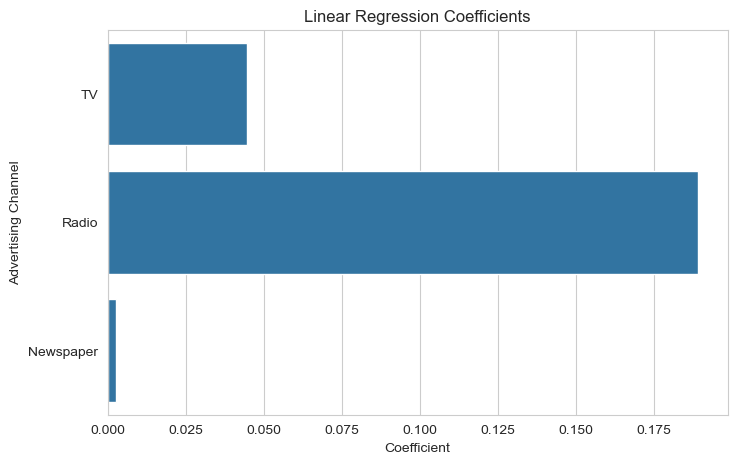

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coefficients,
    x='Coefficient',
    y='Feature'
)

plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Advertising Channel")

plt.show()

Interpretation

The regression coefficients show how the model associates each advertising channel with predicted sales while considering the other advertising variables in the model. The channel with the largest positive coefficient has the largest estimated change in predicted sales per one-unit increase in spending, holding the other features constant. Because the channels may be measured on different scales, coefficients should be interpreted in their original units.

In [36]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
rf_predictions = rf_model.predict(X_test)

In [38]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")
print("-------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest
-------------
MAE : 0.6287125000000021
RMSE: 0.7572349907723515
R²  : 0.9818333477552758


In [39]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        linear_mae,
        rf_mae
    ],
    'RMSE': [
        linear_rmse,
        rf_rmse
    ],
    'R² Score': [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.628713,0.757235,0.981833


In [40]:
best_model_name = results.loc[
    results['R² Score'].idxmax(),
    'Model'
]

print("Best model based on R²:", best_model_name)

Best model based on R²: Random Forest


In [41]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,TV,0.624727
1,Radio,0.362119
2,Newspaper,0.013153


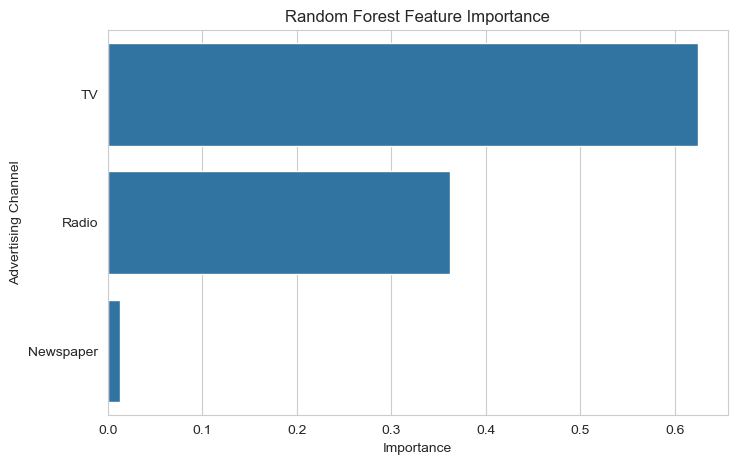

In [42]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

Interpretation

Random Forest feature importance indicates how useful each advertising variable was for the fitted model's predictions. The feature with the largest importance contributed most to the model's predictive decisions. This is a model-specific measure and should not be interpreted as a causal effect.

In [43]:
residuals = y_test - rf_predictions

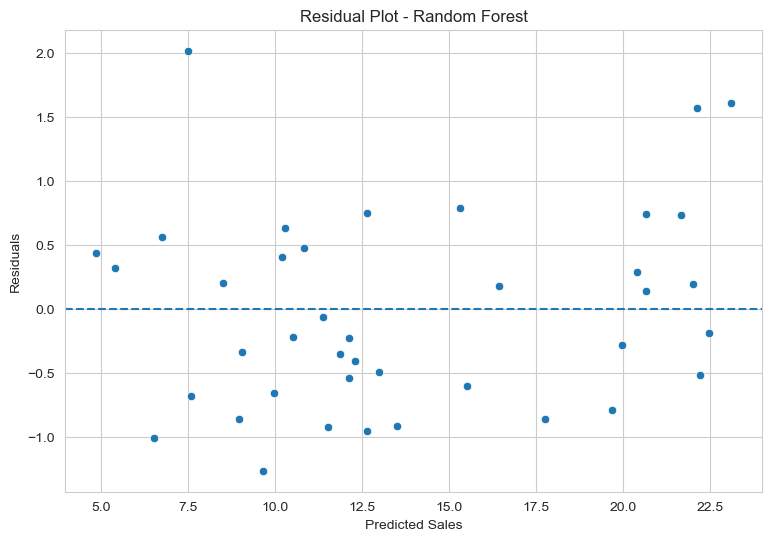

In [44]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=rf_predictions,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title("Residual Plot - Random Forest")
plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")

plt.show()

Residual Analysis

Residuals represent the difference between the actual and predicted sales values. Ideally, residuals should be scattered randomly around zero without a clear curve, trend, or changing spread.

If the residuals show a systematic pattern, this may indicate that the model is not capturing some structure in the relationship between advertising expenditure and sales.

A relatively random distribution around zero suggests that the model's errors do not show an obvious systematic pattern

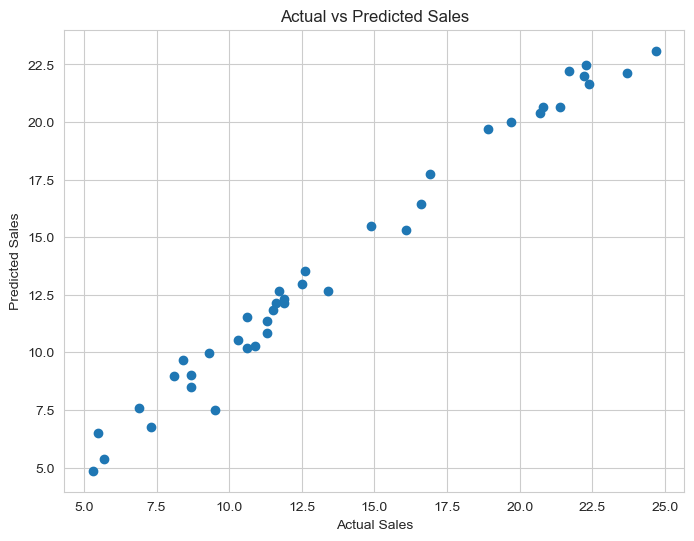

In [45]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [46]:
new_advertising = pd.DataFrame({
    'TV': [150],
    'Radio': [25],
    'Newspaper': [20]
})

In [47]:
predicted_sales = rf_model.predict(new_advertising)

print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 15.163499999999974


Conclusion

In this project, a regression-based sales prediction system was developed using advertising expenditure across TV, Radio, and Newspaper channels.

Exploratory data analysis was performed using descriptive statistics, pairplots, scatter plots, and a correlation heatmap to understand the relationships between advertising expenditure and sales.

Linear Regression was trained as the baseline model, while Random Forest Regressor was used as an additional model. Both models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

The model comparison should be based on the test-set results: lower MAE and RMSE indicate smaller prediction errors, while a higher R² indicates that more variation in sales is explained by the model.

Regression coefficients and Random Forest feature importance were used to interpret the relative contribution of the advertising channels. These measures describe associations learned by the models and should not be interpreted as proof of causal advertising effects.

Residual analysis was also performed to determine whether the selected model's errors appeared randomly distributed or showed systematic patterns.